# Notebook 10 – Target Variable Analysis


# Class Distribution

Class distribution tells us how the target values are distributed among different classes.

For example, in a classification problem, the target may contain:

- Yes
- No

We can check how the observations are divided between these classes.

## Demonstration

If a dataset contains 80 "Yes" values and 20 "No" values, the classes are not equally distributed.

## Implemention

We can use `value_counts()` to see the class distribution.

## Dataset creation

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "Customer": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    "City": [
        "Chennai", "Chennai", "Delhi", "Delhi", "Mumbai",
        "Mumbai", "Chennai", "Kolkata", "Kolkata", "Pune"
    ],
    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Male"
    ],
    "Membership": [
        "Gold", "Silver", "Gold", "Bronze", "Silver",
        "Gold", "Gold", "Silver", "Bronze", "Gold"
    ],
    "Purchased": [
        "Yes", "No", "Yes", "No", "Yes",
        "Yes", "No", "No", "Yes", "Yes"
    ]
})

df

,Customer,City,Gender,Membership,Purchased
0,A,Chennai,Male,Gold,Yes
1,B,Chennai,Female,Silver,No
2,C,Delhi,Male,Gold,Yes
3,D,Delhi,Female,Bronze,No
4,E,Mumbai,Male,Silver,Yes
5,F,Mumbai,Female,Gold,Yes
6,G,Chennai,Male,Gold,No
7,H,Kolkata,Female,Silver,No
8,I,Kolkata,Male,Bronze,Yes
9,J,Pune,Male,Gold,Yes


In [6]:
target = df["Purchased"]

target.value_counts()

,count
Purchased,
Yes,6
No,4


## Explanation

`value_counts()` counts how many observations belong to each target class.

The output shows the distribution of the target variable.

This is useful for understanding the target before training a classification model.

# Class Counts

Class counts show the exact number of observations belonging to each class.

## Demonstration

For example:

Yes → 60

No → 40

This means there are 60 observations in the Yes class and 40 in the No class.

## Implemention

We can use `value_counts()` to calculate the number of observations in each class.

In [7]:
class_counts = df["Purchased"].value_counts()

print(class_counts)

Purchased
Yes    6
No     4
Name: count, dtype: int64


## Explanation

The output gives the number of observations for every class in the target variable.

# Class Percentages

Class percentages show what percentage of the dataset belongs to each target class.

This makes it easier to compare classes when the dataset size is large.

##  Demonstration

If:

Yes → 80%

No → 20%

then most observations belong to the Yes class.

## Implemention

We can use `normalize=True` with `value_counts()` to calculate class percentages.

In [8]:
class_percentages = (
    df["Purchased"].value_counts(normalize=True) * 100
)

print(class_percentages)

Purchased
Yes    60.0
No     40.0
Name: proportion, dtype: float64


## Explanation

`normalize=True` converts the class counts into proportions.

Multiplying by 100 converts those proportions into percentages.

The percentages help us compare the size of each class.

# Class Imbalance


Class imbalance occurs when one class has significantly more observations than another class.

For example:

Yes → 95%

No → 5%

Here, the No class is the minority class.

## Demonstration

In a fraud detection problem, most transactions may be normal while only a small number are fraudulent.

This creates an imbalanced target.

## Implemention

We can examine the class percentages to identify possible imbalance.

In [14]:
class_percentages = (
    df["Purchased"].value_counts(normalize=True) * 100
)

print(class_percentages)

Purchased
Yes    60.0
No     40.0
Name: proportion, dtype: float64


## Explanation

If one class represents a very large percentage of the observations while another class represents a very small percentage, the target may be imbalanced.

Understanding class imbalance is important because a Machine Learning model may favor the majority class.

# Regression Target Variable Analysis

## Concept

In a regression problem, the target variable is a continuous numerical variable that we want the Machine Learning model to predict.

Examples of regression target variables include:

* House Price
* Salary
* Temperature
* Sales
* Age

Before training a regression model, it is important to analyze the target variable separately. This helps us understand its distribution, central tendency, variability, skewness, and the presence of outliers.

In this notebook, we will analyze the following characteristics of the regression target variable:

1. Target Distribution
2. Mean
3. Median
4. Variance
5. Standard Deviation
6. Skewness
7. Outliers


## Demonstration

Suppose we have a dataset containing house information, and our goal is to predict the price of a house.

For example:

| Area | Bedrooms | Age | HousePrice |
| ---- | -------: | --: | ---------: |
| 1200 |        2 |  10 |     250000 |
| 1500 |        3 |   5 |     320000 |
| 1800 |        3 |   8 |     380000 |
| 2200 |        4 |   2 |     450000 |

Here, **HousePrice** is the target variable because it is the value we want the Machine Learning model to predict.

Since HousePrice is a continuous numerical variable, this is a **regression problem**.


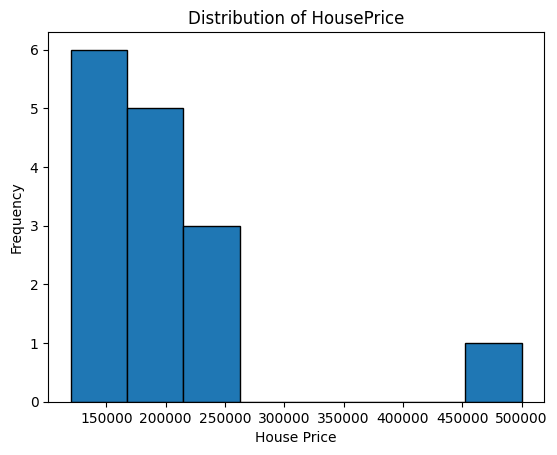

In [24]:
regression_df = pd.DataFrame({
    "HousePrice": [120000, 135000, 142000, 150000, 155000,
                   160000, 168000, 175000, 182000, 190000,
                   205000, 220000, 240000, 260000, 500000]
})

regression_target = regression_df["HousePrice"]
regression_df
plt.hist(regression_target, bins=8, edgecolor="black")
plt.title("Distribution of HousePrice")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

In [26]:
target_column = "HousePrice"

target = regression_df[target_column]

print("Target Variable:")
print(target.head())

Target Variable:
0    120000
1    135000
2    142000
3    150000
4    155000
Name: HousePrice, dtype: int64


## Explanation

The target variable is selected from the dataset and stored in the variable `target`.

The variable `target_column` stores the name of the column that we want to predict.

By separating the target variable from the other features, we can analyze its properties before building a Machine Learning model.


## 1. Target Distribution

### Concept

The distribution of a target variable shows how its values are spread across the dataset.

For a regression problem, the target variable is numerical and continuous. A histogram can be used to visualize how frequently different values occur.

By analyzing the target distribution, we can understand:

* The range of the target values
* Where most values are concentrated
* Whether the distribution is symmetric
* Whether the distribution is skewed
* Whether extreme values are present


### Demonstration

Consider the following target values:

`200000, 220000, 230000, 250000, 260000, 270000, 500000`

Most values are concentrated between 200000 and 270000, while 500000 is much larger than the other values.

A histogram helps us visualize this pattern and identify the overall shape of the target distribution.


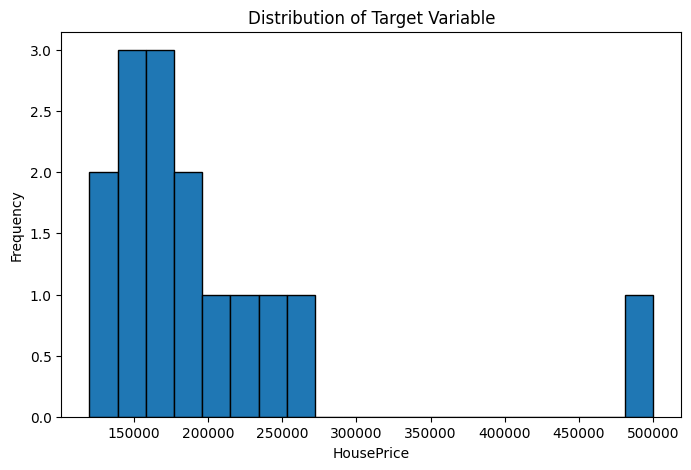

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(target, bins=20, edgecolor="black")

plt.title("Distribution of Target Variable")
plt.xlabel(target_column)
plt.ylabel("Frequency")

plt.show()

### Explanation

The histogram shows the distribution of the target variable.

The x-axis represents the values of the target variable, while the y-axis represents how frequently those values occur.

By observing the histogram, we can determine whether the target variable is normally distributed, skewed, or affected by extreme values.


## 2. Mean

### Concept

The mean represents the average value of the target variable.

It is calculated by adding all target values and dividing the result by the total number of observations.

The mean provides a general idea of the central value of the target variable.

However, the mean can be strongly affected by extreme values or outliers.


### Demonstration

Consider the following target values:

`10, 20, 30, 40, 50`

The mean is:

`(10 + 20 + 30 + 40 + 50) / 5 = 30`

Therefore, the average target value is 30.


In [28]:
mean_value = target.mean()

print("Mean of Target Variable:", mean_value)

Mean of Target Variable: 200133.33333333334


### Explanation

The `mean()` function calculates the average value of the target variable.

This gives us an overall estimate of the central tendency of the target values.

If the dataset contains extreme values, the mean may be pulled towards those values.


## 3. Median

### Concept

The median is the middle value of the target variable after arranging all values in ascending order.

Unlike the mean, the median is less affected by extreme values.

Comparing the mean and median can provide information about the shape of the distribution.


### Demonstration

Consider the following target values:

`10, 20, 30, 40, 50`

The middle value is:

`30`

Therefore, the median is 30.

If we add an extreme value, such as:

`10, 20, 30, 40, 50, 1000`

The mean will increase significantly, while the median will be less affected.


In [29]:
median_value = target.median()

print("Median of Target Variable:", median_value)

Median of Target Variable: 175000.0


### Explanation

The `median()` function calculates the middle value of the target variable.

The median is particularly useful when the target variable contains outliers because it is more robust to extreme values than the mean.


## 4. Variance

### Concept

Variance measures how far the target values are spread from their mean.

A low variance indicates that the target values are relatively close to the mean.

A high variance indicates that the target values are spread over a wider range.

Variance is calculated using the squared differences between each value and the mean.


### Demonstration

Consider two groups of target values:

**Group A:** `48, 49, 50, 51, 52`

**Group B:** `10, 30, 50, 70, 90`

Both groups may have a similar mean, but Group B has values that are more widely spread.

Therefore, Group B has a higher variance than Group A.


In [30]:
variance_value = target.var()

print("Variance of Target Variable:", variance_value)

Variance of Target Variable: 8415123809.5238085


### Explanation

The `var()` function calculates the variance of the target variable.

A higher variance indicates greater variability in the target values, while a lower variance indicates that the values are more concentrated around the mean.


## 5. Standard Deviation

### Concept

Standard deviation measures how much the target values typically differ from the mean.

It is the square root of the variance.

Standard deviation is useful because it is expressed in the same unit as the target variable, making it easier to interpret than variance.


### Demonstration

Suppose two target variables have the same mean.

If one target variable has values close to the mean, it will have a low standard deviation.

If another target variable has values spread far from the mean, it will have a high standard deviation.

Therefore, standard deviation helps us understand the amount of variation in the target variable.


In [ ]:
std_value = target.std()

print("Standard Deviation of Target Variable:", std_value)

### Explanation

The `std()` function calculates the standard deviation of the target variable.

A low standard deviation indicates that most values are close to the mean.

A high standard deviation indicates that the target values are more widely distributed.


## 6. Skewness

### Concept

Skewness measures the asymmetry of the distribution of the target variable.

A distribution can be:

* **Approximately symmetric:** Skewness is close to 0.
* **Positively skewed:** The distribution has a longer tail towards larger values.
* **Negatively skewed:** The distribution has a longer tail towards smaller values.

Understanding skewness is important because a highly skewed target variable may affect the performance of some regression models.


### Demonstration

Consider the following values:

`10, 12, 13, 14, 15, 16, 100`

Most values are concentrated at the lower end, while one large value creates a long tail towards the right.

This represents a **positively skewed distribution**.

Similarly, if most values are high but a few values are very small, the distribution may be negatively skewed.


In [31]:
skewness_value = target.skew()

print("Skewness of Target Variable:", skewness_value)

Skewness of Target Variable: 2.7677678854731065


### Explanation

The `skew()` function calculates the skewness of the target variable.

A skewness value close to 0 indicates an approximately symmetric distribution.

A positive value indicates positive skewness, while a negative value indicates negative skewness.

A strongly skewed target may sometimes benefit from transformations, such as a logarithmic transformation, depending on the Machine Learning model and the characteristics of the data.


## 7. Outlier Analysis

### Concept

Outliers are observations that are significantly different from most other observations in the dataset.

Outliers in the target variable can influence:

* Mean
* Variance
* Standard Deviation
* Model training
* Model performance

One common method for detecting outliers is the **Interquartile Range (IQR) method**.

The IQR is calculated as:

`IQR = Q3 - Q1`

Where:

* Q1 is the first quartile
* Q3 is the third quartile

The lower and upper bounds are then calculated to identify potential outliers.


### Demonstration

Suppose:

* Q1 = 20
* Q3 = 40

Then:

`IQR = 40 - 20 = 20`

The lower bound and upper bound can be calculated using the IQR.

Any values outside these bounds may be considered potential outliers.

These observations should be investigated before deciding whether they represent errors or valid extreme values.


In [32]:
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = target[
    (target < lower_bound) | (target > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Outliers:", len(outliers))

print("\nOutlier Values:")
print(outliers)

Q1: 152500.0
Q3: 212500.0
IQR: 60000.0
Lower Bound: 62500.0
Upper Bound: 302500.0

Number of Outliers: 1

Outlier Values:
14    500000
Name: HousePrice, dtype: int64


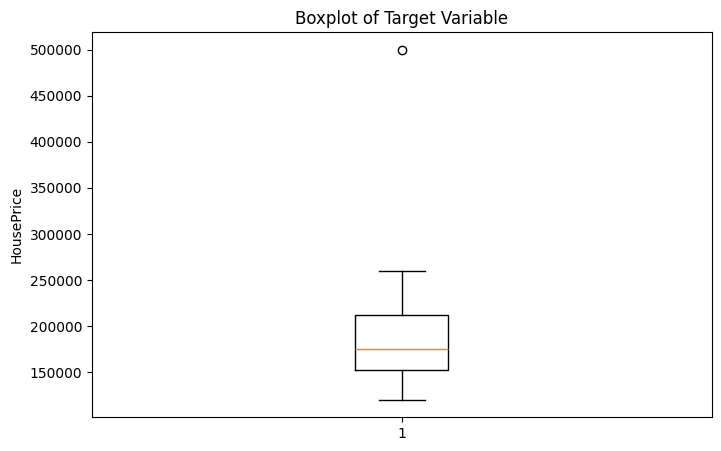

In [33]:
plt.figure(figsize=(8, 5))

plt.boxplot(target)

plt.title("Boxplot of Target Variable")
plt.ylabel(target_column)

plt.show()

### Explanation

The IQR method is used to identify potential outliers in the target variable.

First, the first quartile (Q1) and third quartile (Q3) are calculated.

The Interquartile Range is then calculated as:

`IQR = Q3 - Q1`

Values below the lower bound or above the upper bound are identified as potential outliers.

The boxplot provides a visual representation of the distribution and makes unusual values easier to identify.

However, outliers should not automatically be removed. They may represent valid observations, important rare cases, or data errors. Therefore, they should be investigated before making any preprocessing decisions.
